# Descrição do Projeto

Você é analista em uma grande loja online. Junto com o departamento de marketing, você compilou uma lista de hipóteses que podem ajudar a aumentar a receita. Você precisa priorizar essas hipóteses, lançar um teste A/B e analisar os resultados.

In [1]:
# importar bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import mannwhitneyu

## Priorizando Hipóteses

In [2]:
#ler o arquivo
hypotheses = pd.read_csv('/datasets/hypotheses_us.csv',sep=';')
hypotheses

,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5


- Aplicar o framework ICE para priorizar hipóteses. Classificar em ordem decrescente de prioridade.

In [3]:
ICE = ((hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']).sort_values(ascending=False)
print(ICE)

8    16.200000
0    13.333333
7    11.200000
6     8.000000
2     7.000000
1     2.000000
5     1.333333
3     1.125000
4     1.000000
dtype: float64


- Aplicar o framework RICE para priorizar hipóteses. Classificar em ordem decrescente de prioridade.

In [4]:
RICE = ((hypotheses['Reach'] * hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']).sort_values(ascending=False)
print(RICE)

7    112.0
2     56.0
0     40.0
6     40.0
8     16.2
3      9.0
1      4.0
5      4.0
4      3.0
dtype: float64


- Temos que o top 5 de ambos frameworks contem as mesmas hipoteses, porem em posições diferentes. Como RICE leva em cosidereção o alcance tambem, enquanto ICE apenas o impacto e a confiança, hipoteses que possuem um alcance maior se destacam mais nesse framework.

## Análise de teste A/B

### Carregar e pré-processar os dados

In [5]:
# ler os arquivos
raw_orders = pd.read_csv('/datasets/orders_us.csv')
print(raw_orders.info())
visits = pd.read_csv('/datasets/visits_us.csv')
print(visits.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB
None


In [6]:
# Converter a coluna de data para o tipo datetime
raw_orders['date'] = pd.to_datetime(raw_orders['date'])
visits['date'] = pd.to_datetime(visits['date'])

# Encontrar usuários que aparecem em mais de um grupo
user_groups = raw_orders.groupby('visitorId')['group'].nunique()
multi_group_users = user_groups[user_groups > 1].index

# Remover esses usuários do dataframe
orders = raw_orders[~raw_orders['visitorId'].isin(multi_group_users)].reset_index()

### Receita acumulada

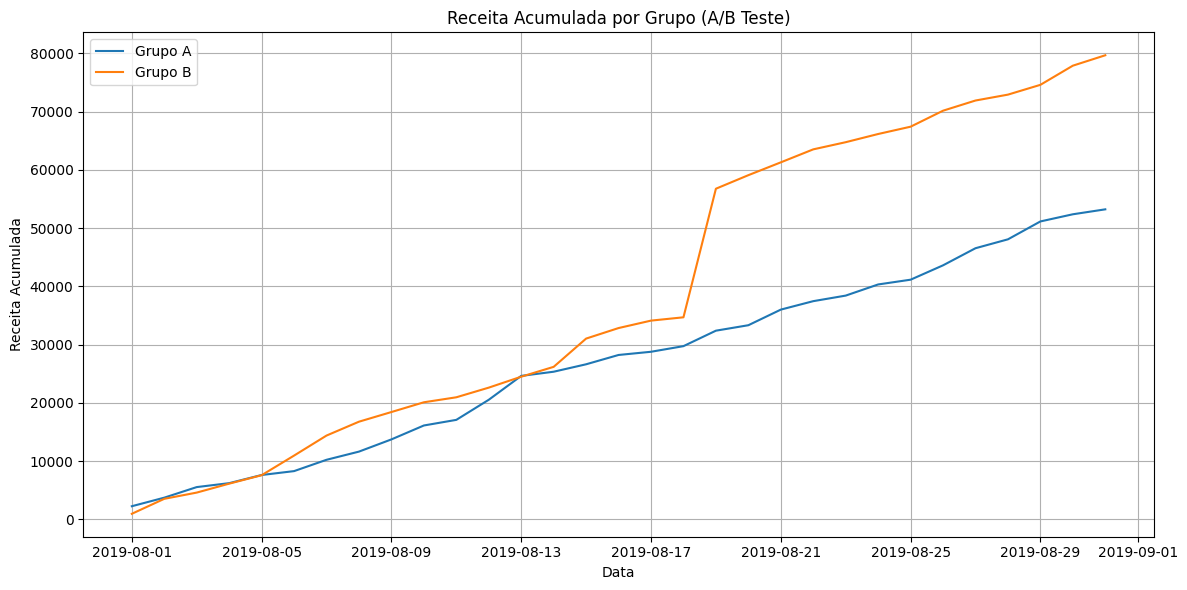

In [7]:
# Calcular a receita acumulada por grupo ao longo do tempo
cumulative_revenue = (
    orders
    .groupby(['date', 'group'])['revenue']
    .sum()
    .groupby(level=1)
    .cumsum()
    .reset_index()
)

# Plotar
plt.figure(figsize=(12, 6))
for group in cumulative_revenue['group'].unique():
    group_data = cumulative_revenue[cumulative_revenue['group'] == group]
    plt.plot(group_data['date'], group_data['revenue'], label=f'Grupo {group}')

plt.title('Receita Acumulada por Grupo (A/B Teste)')
plt.xlabel('Data')
plt.ylabel('Receita Acumulada')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

- O grupo B demonstra resultado relativamente igual ao grupo A pelas primeiras duas semanas (ate dia 18) e então demonstra um crescimento expressivo até o final do teste, pode ser necessário revisar se há outliers afetando a análise.

### Tamanho médio acumulado do pedido

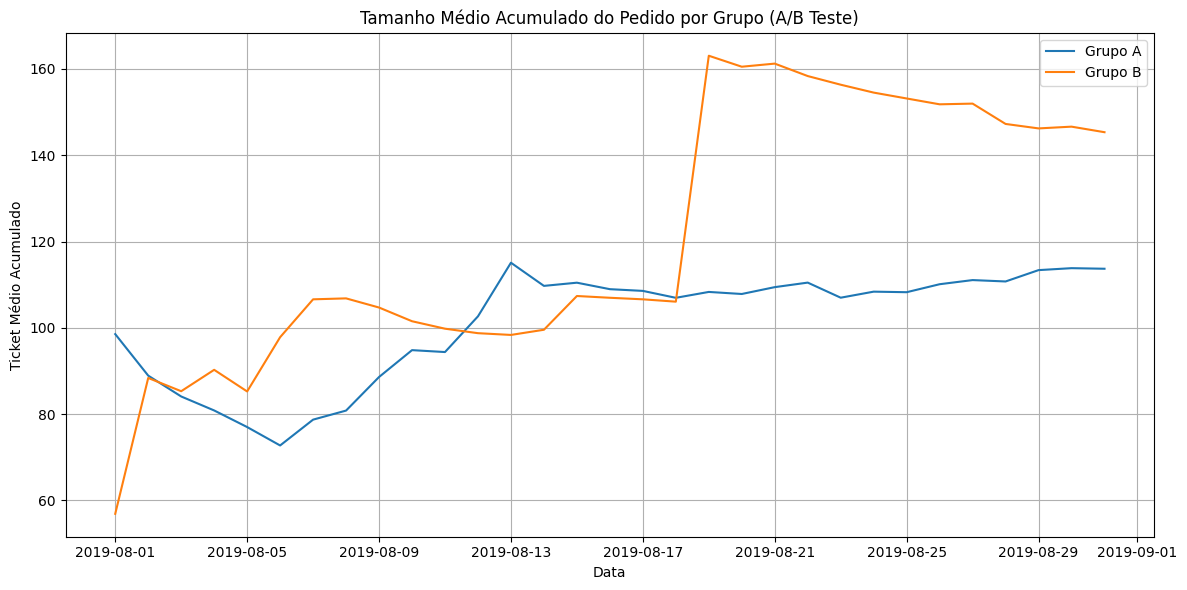

In [8]:
# Calcular receita acumulada e número de pedidos acumulados por grupo
cumulative = (
    orders
    .groupby(['date', 'group'])
    .agg({'revenue': 'sum', 'transactionId': 'count'})
    .rename(columns={'transactionId': 'orders'})
    .groupby(level=1)
    .cumsum()
    .reset_index()
)

# Calcular o ticket médio acumulado
cumulative['avg_order_value'] = cumulative['revenue'] / cumulative['orders']

# Plotar
plt.figure(figsize=(12, 6))
for group in cumulative['group'].unique():
    group_data = cumulative[cumulative['group'] == group]
    plt.plot(group_data['date'], group_data['avg_order_value'], label=f'Grupo {group}')

plt.title('Tamanho Médio Acumulado do Pedido por Grupo (A/B Teste)')
plt.xlabel('Data')
plt.ylabel('Ticket Médio Acumulado')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

- Mais uma vez, depois de não variar muito pelas primeiras semanas, a partir do dia 18 temos um crescimento significativo nos resultados do grupo B em relação ao A, o que reforça a necessidade de analisar a possivel causa dessa mudança (outliers ou eventos externos).

### Diferença relativa no tamanho médio acumulado

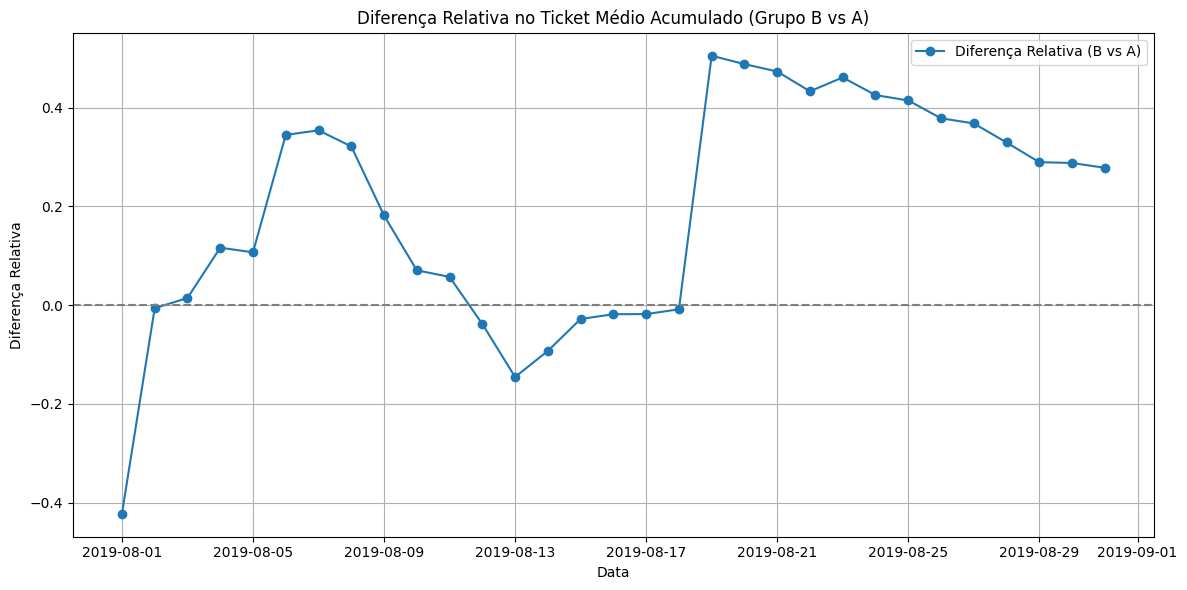

In [9]:
# Separar os dados dos grupos A e B
cumulative_A = cumulative[cumulative['group'] == 'A'][['date', 'avg_order_value']]
cumulative_B = cumulative[cumulative['group'] == 'B'][['date', 'avg_order_value']]

# Juntar por data
merged = pd.merge(cumulative_A, cumulative_B, on='date', how='inner', suffixes=('_A', '_B'))

# Calcular diferença relativa
merged['relative_diff'] = (merged['avg_order_value_B'] - merged['avg_order_value_A']) / merged['avg_order_value_A']

# Plotar
plt.figure(figsize=(12, 6))
plt.plot(merged['date'], merged['relative_diff'], marker='o', label='Diferença Relativa (B vs A)')

plt.axhline(y=0, color='gray', linestyle='--')
plt.title('Diferença Relativa no Ticket Médio Acumulado (Grupo B vs A)')
plt.xlabel('Data')
plt.ylabel('Diferença Relativa')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

- Temos bastante oscilação e mudanças bruscas entre o grupo B e o grupo A, indicando possiveis outliers. Nesse caso, pode ser útil analisar a mediana ou aplicar tratamento de outliers.

### Taxas de conversão diárias

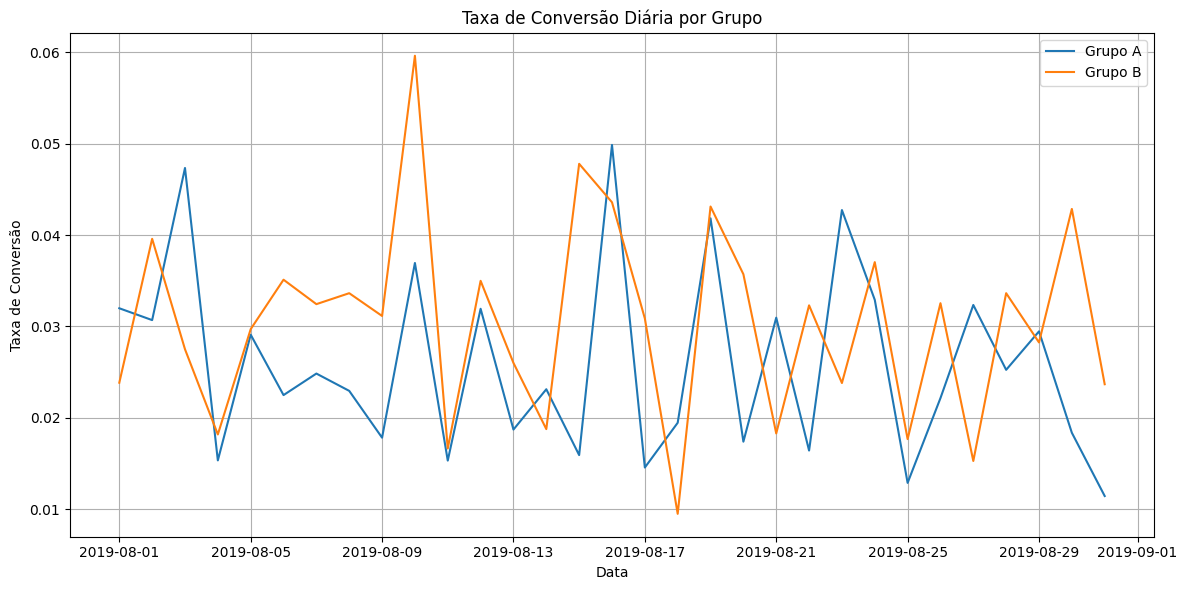

In [10]:
# Agrupar pedidos por dia e grupo
daily_orders = orders.groupby(['date', 'group'])['transactionId'].nunique().reset_index()
daily_orders.rename(columns={'transactionId': 'orders'}, inplace=True)

# Juntar com o dataframe de visitas
conversion = pd.merge(visits, daily_orders, on=['date', 'group'], how='left')

# Calcular taxa de conversão
conversion['conversion_rate'] = conversion['orders'] / conversion['visits']

# Plotar
plt.figure(figsize=(12, 6))
for group in conversion['group'].unique():
    group_data = conversion[conversion['group'] == group]
    plt.plot(group_data['date'], group_data['conversion_rate'], label=f'Grupo {group}')

plt.title('Taxa de Conversão Diária por Grupo')
plt.xlabel('Data')
plt.ylabel('Taxa de Conversão')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

- As taxas diárias de conversão variam bastante, onde o grupo B parece ter uma taxa media um pouco maior mas não tão significativa em relação ao A, precisamos analisar mais a fundo a diferença relativa.

### Diferença relativa na conversão cumulativa

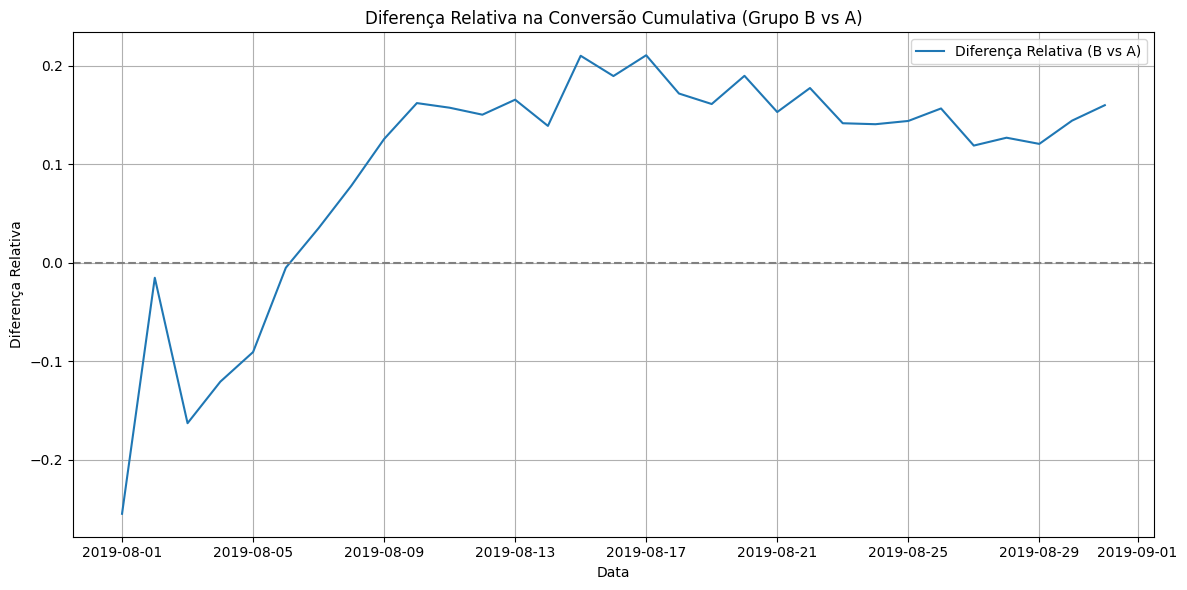

In [11]:
# Cálculo de visitas acumuladas por grupo
cumulative_visits = (
    visits
    .groupby('group')
    .apply(lambda x: x.sort_values('date').assign(cum_visits=x['visits'].cumsum()))
    .reset_index(drop=True)
)

# Cálculo de pedidos acumulados por grupo
cumulative_orders = (
    orders
    .groupby(['date', 'group'])['transactionId']
    .nunique()
    .reset_index()
    .rename(columns={'transactionId': 'orders'})
)

cumulative_orders = (
    cumulative_orders
    .groupby('group')
    .apply(lambda x: x.sort_values('date').assign(cum_orders=x['orders'].cumsum()))
    .reset_index(drop=True)
)

# Juntar dados de visitas e pedidos
cumulative_data = pd.merge(
    cumulative_visits[['date', 'group', 'cum_visits']],
    cumulative_orders[['date', 'group', 'cum_orders']],
    on=['date', 'group'],
    how='inner'
)

# Calcular taxa de conversão cumulativa
cumulative_data['conversion'] = cumulative_data['cum_orders'] / cumulative_data['cum_visits']

# Separar A e B para comparação
cum_A = cumulative_data[cumulative_data['group'] == 'A'][['date', 'conversion']]
cum_B = cumulative_data[cumulative_data['group'] == 'B'][['date', 'conversion']]
merged = pd.merge(cum_A, cum_B, on='date', suffixes=('_A', '_B'))

# Diferença relativa
merged['relative_diff'] = (merged['conversion_B'] - merged['conversion_A']) / merged['conversion_A']

# Plotar
plt.figure(figsize=(12, 6))
plt.plot(merged['date'], merged['relative_diff'], label='Diferença Relativa (B vs A)')
plt.axhline(y=0, color='gray', linestyle='--')
plt.title('Diferença Relativa na Conversão Cumulativa (Grupo B vs A)')
plt.xlabel('Data')
plt.ylabel('Diferença Relativa')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

- A diferença relativa da taxa de conversão cumulativa do grupo B em relação ao A tem um valor que cresce a partir do dia 5 e se mantem constantemente maior até o final do teste, podendo significar uma real difereça etre os grupos, mas ainda demanda uma análise para ver se é estatisticamente significativa.

### Anomalia na quantidade de pedidos

In [12]:
# Contar número de pedidos por usuário
orders_per_user = orders.groupby('visitorId')['transactionId'].nunique()

# Calcular percentis
p95 = np.percentile(orders_per_user, 95)
p99 = np.percentile(orders_per_user, 99)

print(f'Percentil 95: {p95}')
print(f'Percentil 99: {p99}')


Percentil 95: 1.0
Percentil 99: 2.0


- Usuários com 3 pedidos ou mais são considerados uma anomalia.

### Gráfico de dispersão dos preços dos pedidos

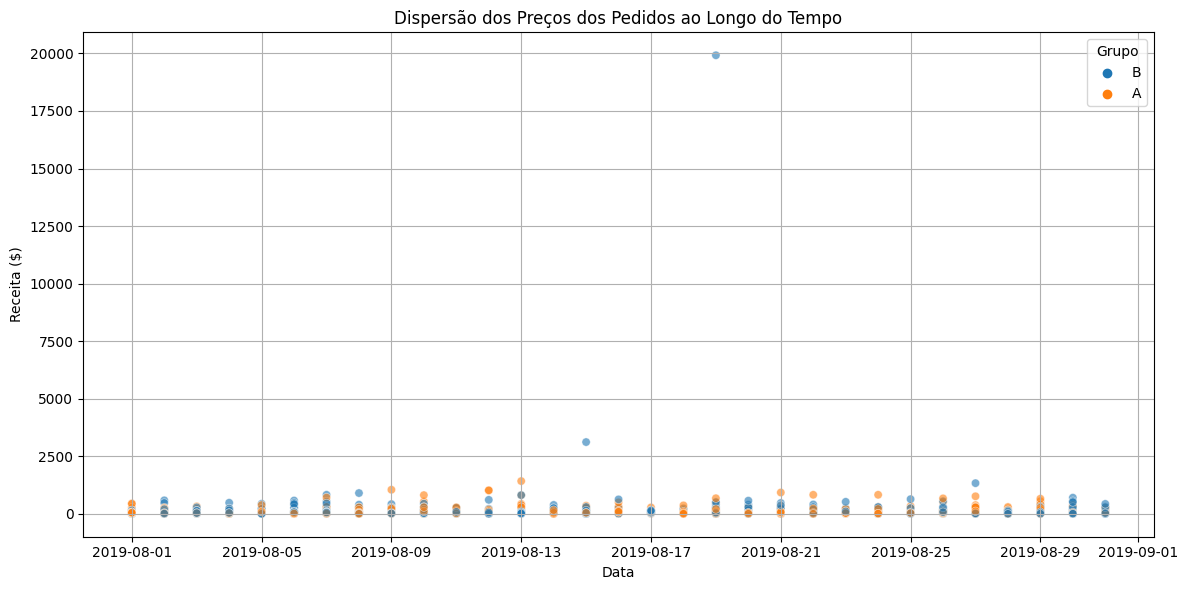

In [13]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=orders, x='date', y='revenue', hue='group', alpha=0.6)

plt.title('Dispersão dos Preços dos Pedidos ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Receita ($)')
plt.grid(True)
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

- Os preços dos pedidos ficam em grande parte abaixo de ~2,000, e podemos ver dois outliers bem claros no grupo B, um deles sendo de 20,000, o que causa uma distorção nas métricas que estamos analisando. Pode ser útil capar os valores extremos (ex: acima do percentil 99) para análises mais estáveis.

### Anomalia no preço dos pedidos

In [14]:
# Calcular percentis dos valores de pedidos
p95_revenue = np.percentile(orders['revenue'], 95)
p99_revenue = np.percentile(orders['revenue'], 99)

print(f'Percentil 95: R$ {p95_revenue:,.2f}')
print(f'Percentil 99: R$ {p99_revenue:,.2f}')

Percentil 95: R$ 414.27
Percentil 99: R$ 830.30


- Pedidos maiores que $830 são considerados anomalias.

### Significância estatística da diferença na conversão (dados brutos)

In [22]:
# Separar os dados por pedido por usuario
ordersByUsersA = orders[orders['group']=='A'].groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})
ordersByUsersA.columns = ['visitorId', 'orders']

ordersByUsersB = orders[orders['group']=='B'].groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})
ordersByUsersB.columns = ['visitorId', 'orders']

# montar a amostra de conversão
sampleA = pd.concat([ordersByUsersA['orders'],pd.Series(0, index=np.arange(visits[visits['group']=='A']['visits'].sum() - len(ordersByUsersA['orders'])), name='orders')],axis=0)
sampleB = pd.concat([ordersByUsersB['orders'],pd.Series(0, index=np.arange(visits[visits['group']=='B']['visits'].sum() - len(ordersByUsersB['orders'])), name='orders')],axis=0)

# Teste de Mann-Whitney U
results = mannwhitneyu(sampleA, sampleB) 
print('p-value: ', results.pvalue)

if (results.pvalue < alpha): 
    print("Hipótese nula rejeitada: a diferença possui significância estatística") 
else: 
    print("Falha a rejeitar a hipótese nula: não é possível chegar a conclusões sobre a diferença")

p-value:  0.011018084110014696
Hipótese nula rejeitada: a diferença possui significância estatística


- A diferença na conversão entre os grupos possui uma significância estatística, usando os dados brutos. Pode ser útil também analisar os dados filtrados de outliers para ser tomada uma decisão.

### Significancia estatística da diferença no tamanho médio do pedido (dados brutos)

In [16]:
# nível de significância 
alpha = .05

# Separar os dados de receita por grupo
a_orders = orders[orders['group'] == 'A']['revenue']
b_orders = orders[orders['group'] == 'B']['revenue']

# Teste de Mann-Whitney U
results = mannwhitneyu(a_orders, b_orders) 
print('p-value: ', results.pvalue)

if (results.pvalue < alpha): 
    print("Hipótese nula rejeitada: a diferença possui significância estatística") 
else: 
    print("Falha a rejeitar a hipótese nula: não é possível chegar a conclusões sobre a diferença")

p-value:  0.8622329690015668
Falha a rejeitar a hipótese nula: não é possível chegar a conclusões sobre a diferença


- A diferença no tamanho médio do pedido entre os grupos não possui significância estatística para ser considerada, usando os dados brutos.

### Significância estatística da diferença na conversão (dados filtrados)

In [25]:
# Separando os usuários anormais
usersWithManyOrders = pd.concat([ordersByUsersA[ordersByUsersA['orders'] >=3]['visitorId'], ordersByUsersB[ordersByUsersB['orders'] >=3]['visitorId']], axis = 0)
usersWithExpensiveOrders = orders[orders['revenue'] > 830]['visitorId']
abnormalUsers = pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis = 0).drop_duplicates().sort_values()

# Filtrando os dados
sampleAFiltered = pd.concat([ordersByUsersA[np.logical_not(ordersByUsersA['visitorId'].isin(abnormalUsers))]['orders'],pd.Series(0, index=np.arange(visits[visits['group']=='A']['visits'].sum() - len(ordersByUsersA['orders'])),name='orders')],axis=0)
sampleBFiltered = pd.concat([ordersByUsersB[np.logical_not(ordersByUsersB['visitorId'].isin(abnormalUsers))]['orders'],pd.Series(0, index=np.arange(visits[visits['group']=='B']['visits'].sum() - len(ordersByUsersB['orders'])),name='orders')],axis=0)

# Aplicando o teste na amostra filtrada
results = mannwhitneyu(sampleAFiltered, sampleBFiltered) 
print('p-value: ', results.pvalue)

if (results.pvalue < alpha): 
    print("Hipótese nula rejeitada: a diferença possui significância estatística") 
else: 
    print("Falha a rejeitar a hipótese nula: não é possível chegar a conclusões sobre a diferença")

p-value:  0.00628825819911193
Hipótese nula rejeitada: a diferença possui significância estatística


-  Usando os dados filtrados obtvemos que a diferença possui significancia estatistica, o que comprova que o grupo B realmente tem uma conversão melhor em relação ao grupo A.

### Significancia estatística da diferença no tamanho médio do pedido (dados filtrados)

In [27]:
# Filtrar os dados de receita por grupo
a_orders_filtered = orders[np.logical_and(
        orders['group']=='A',
        np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue']
b_orders_filtered = orders[np.logical_and(
        orders['group']=='B',
        np.logical_not(orders['visitorId'].isin(abnormalUsers)))]['revenue']

# Teste de Mann-Whitney U
results = mannwhitneyu(a_orders_filtered, b_orders_filtered) 
print('p-value: ', results.pvalue)

if (results.pvalue < alpha): 
    print("Hipótese nula rejeitada: a diferença possui significância estatística") 
else: 
    print("Falha a rejeitar a hipótese nula: não é possível chegar a conclusões sobre a diferença")

p-value:  0.8767101122551697
Falha a rejeitar a hipótese nula: não é possível chegar a conclusões sobre a diferença


- A diferença no tamanho médio do pedido entre os grupos não possui significância estatística para ser considerada, mesmo com os dados filtrados. 

### Conclusão

    Com base nos resultados podemos parar os testes e considerar o grupo B o líder, onde ambos não tem diferença no tamanho médio por pedido, mas o B tendo uma melhora significativa na conversão.